# Import thư viện và cấu hình

In [ ]:
import os
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import make_classification, make_moons
from sklearn.calibration import calibration_curve

from scipy.stats import chi2, binomtest

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

# ===== PATH =====
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(os.path.dirname(CURRENT_DIR))
DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
FIG_PATH = os.path.join(BASE_DIR, "report", "figures", "perceptron_logreg")
PKL_PATH = os.path.join(DATA_DIR, "processed_data.pkl")

os.makedirs(FIG_PATH, exist_ok=True)

TARGET_COL = "satisfaction" 

print("Thư viện + path đã cấu hình xong.")

Thư viện + path đã cấu hình xong.


# Load dữ liệu 
Dữ liệu được load từ file `processed_data.pkl`, là kết quả của pipeline tiền xử lý đã thực hiện trước đó.  
Cách làm này giúp:
- giữ nguyên preprocessing giữa các notebook
- tránh data leakage
- đảm bảo khả năng tái lập thí nghiệm

In [ ]:
with open(PKL_PATH, "rb") as f:
    processed = pickle.load(f)

X_train = processed["X_train"]
y_train = processed["y_train"]
X_val   = processed["X_val"]
y_val   = processed["y_val"]
X_test  = processed["X_test"]
y_test  = processed["y_test"]

CLASS_WEIGHTS = {int(k): float(v) for k, v in processed["class_weights"].items()}
FEATURE_COLS  = processed["feature_cols"]
SCALE_COLS    = processed["scale_cols"]

# đổi sang numpy cho dễ code from-scratch
X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train

X_val_np = X_val.values if isinstance(X_val, pd.DataFrame) else X_val
y_val_np = y_val.values if isinstance(y_val, pd.Series) else y_val

X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

print("Train:", X_train_np.shape, y_train_np.shape)
print("Val  :", X_val_np.shape, y_val_np.shape)
print("Test :", X_test_np.shape, y_test_np.shape)
print("Class weights:", CLASS_WEIGHTS)

Train: (90916, 24) (90916,)
Val  : (12988, 24) (12988,)
Test : (25976, 24) (25976,)
Class weights: {0: 0.8823540829596848, 1: 1.153844201335127}


# Hàm đánh giá chung

Phần này định nghĩa một hàm tiện ích để đánh giá mô hình bằng các chỉ số:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Đối với Logistic Regression, notebook còn báo cáo thêm:
- ROC-AUC
- Average Precision (AP)

In [ ]:
def evaluate_classification(y_true, y_pred, y_proba=None, model_name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("Confusion Matrix:")
    print(cm)

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        brier = brier_score_loss(y_true, y_proba)

        print(f"ROC-AUC  : {auc:.4f}")
        print(f"AP       : {ap:.4f}")
        print(f"Brier    : {brier:.4f}")

        result["roc_auc"] = auc
        result["ap"] = ap
        result["brier"] = brier

    return result

# A - PERCEPTRON

## 1. Cơ sở lý thuyết
Perceptron là một thuật toán phân loại tuyến tính đơn giản, hoạt động dựa trên: $$ y = sign(w^T x + b) $$
Thuật toán cập nhật trọng số khi dự đoán sai: $$ w = w + \eta \cdot y_i \cdot x_i $$
Trong đó:
- $ \eta $: learning rate
- $ y_i \in \{-1, +1\} $

Theo định lý hội tụ Perceptron:
- nếu dữ liệu **phân chia tuyến tính**, thuật toán sẽ hội tụ sau hữu hạn bước
- nếu dữ liệu **không phân chia tuyến tính**, số lỗi không thể giảm về 0 hoàn toàn

## 2. Cài đặt Perceptron từ đầu

In [ ]:
class PerceptronScratch:
    def __init__(self, lr=0.01, n_iters=100, shuffle=True, random_state=42):
        self.lr = lr
        self.n_iters = n_iters
        self.shuffle = shuffle
        self.random_state = random_state
        self.w = None
        self.b = None
        self.errors_per_epoch = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.errors_per_epoch = []

        y_signed = np.where(y == 1, 1, -1)

        for epoch in range(self.n_iters):
            errors = 0
            indices = np.arange(n_samples)

            if self.shuffle:
                rng.shuffle(indices)

            for i in indices:
                xi = X[i]
                yi = y_signed[i]

                activation = np.dot(xi, self.w) + self.b
                pred = 1 if activation >= 0 else -1

                if pred != yi:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1

            self.errors_per_epoch.append(errors)
            
            if errors == 0:
                print(f"Thuật toán hội tụ tại epoch {epoch+1} (0 lỗi phân loại).")
                break

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

## 3. Thực nghiệm kiểm chứng hội tụ của Perceptron

Để minh họa trực quan định lý hội tụ, ta thử Perceptron trên:
1. Dữ liệu phân chia tuyến tính
2. Dữ liệu không phân chia tuyến tính

### 3.1. Dữ liệu phân chia tuyến tính

In [ ]:
X_lin, y_lin = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.5,
    flip_y=0.0,
    random_state=SEED
)

perc_lin = PerceptronScratch(lr=0.01, n_iters=200, shuffle=True, random_state=SEED)
perc_lin.fit(X_lin, y_lin)
y_lin_pred = perc_lin.predict(X_lin)

lin_result = evaluate_classification(y_lin, y_lin_pred, model_name="Perceptron - Dữ liệu tuyến tính")

Thuật toán hội tụ tại epoch 120 (0 lỗi phân loại).

===== Perceptron - Dữ liệu tuyến tính =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400

Confusion Matrix:
[[200   0]
 [  0 200]]


### 3.2. Dữ liệu không phân chia tuyến tính

In [ ]:
X_moon, y_moon = make_moons(n_samples=400, noise=0.2, random_state=SEED)

perc_moon = PerceptronScratch(lr=0.01, n_iters=200, shuffle=True, random_state=SEED)
perc_moon.fit(X_moon, y_moon)
y_moon_pred = perc_moon.predict(X_moon)

moon_result = evaluate_classification(y_moon, y_moon_pred, model_name="Perceptron - Dữ liệu phi tuyến")


===== Perceptron - Dữ liệu phi tuyến =====
Accuracy : 0.8000
Precision: 0.8191
Recall   : 0.7700
F1-score : 0.7938

Classification Report:
              precision    recall  f1-score   support

           0     0.7830    0.8300    0.8058       200
           1     0.8191    0.7700    0.7938       200

    accuracy                         0.8000       400
   macro avg     0.8011    0.8000    0.7998       400
weighted avg     0.8011    0.8000    0.7998       400

Confusion Matrix:
[[166  34]
 [ 46 154]]


## 4. Trực quan hóa Perceptron

### 4.1. Biểu đồ hội tụ

Đồ thị dưới đây thể hiện số mẫu phân loại sai theo từng vòng lặp, giúp quan sát quá trình hội tụ của Perceptron.

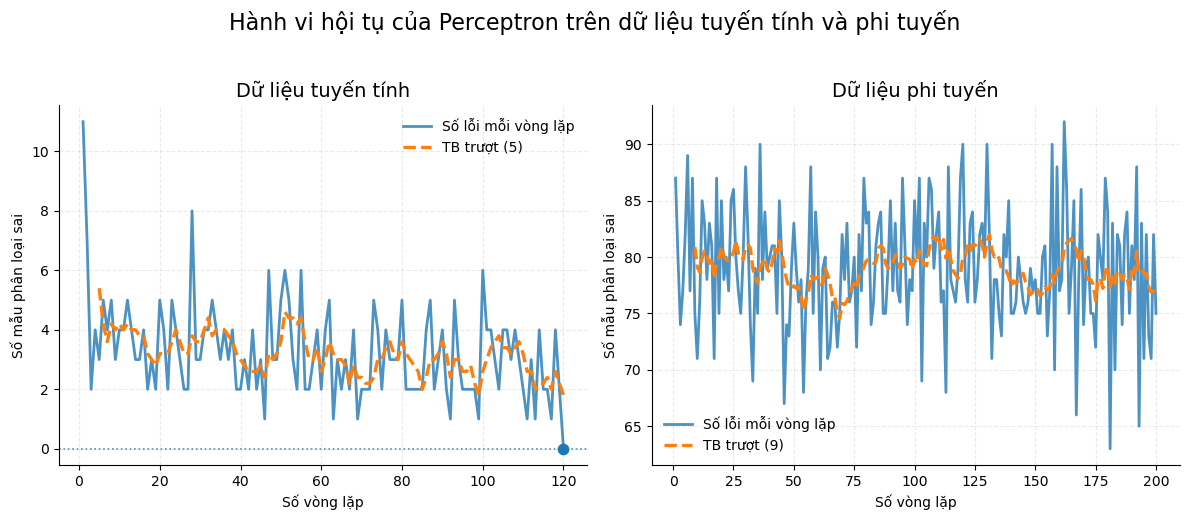

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dữ liệu tuyến tính
epochs_lin = np.arange(1, len(perc_lin.errors_per_epoch) + 1)
axes[0].plot(epochs_lin, perc_lin.errors_per_epoch, linewidth=2, alpha=0.8, label="Số lỗi mỗi vòng lặp")
if len(perc_lin.errors_per_epoch) >= 5:
    smooth_lin = np.convolve(perc_lin.errors_per_epoch, np.ones(5)/5, mode="valid")
    axes[0].plot(np.arange(5, len(perc_lin.errors_per_epoch)+1), smooth_lin,
                 linewidth=2.4, linestyle="--", label="TB trượt (5)")
if perc_lin.errors_per_epoch[-1] == 0:
    axes[0].axhline(0, linestyle=":", linewidth=1.2, alpha=0.8)
    axes[0].scatter(epochs_lin[-1], 0, s=55, zorder=5)
axes[0].set_title("Dữ liệu tuyến tính", fontsize=14)
axes[0].set_xlabel("Số vòng lặp")
axes[0].set_ylabel("Số mẫu phân loại sai")
axes[0].grid(True, linestyle="--", alpha=0.25)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend(frameon=False)

# Dữ liệu phi tuyến
epochs_moon = np.arange(1, len(perc_moon.errors_per_epoch) + 1)
axes[1].plot(epochs_moon, perc_moon.errors_per_epoch, linewidth=2, alpha=0.8, label="Số lỗi mỗi vòng lặp")
if len(perc_moon.errors_per_epoch) >= 9:
    smooth_moon = np.convolve(perc_moon.errors_per_epoch, np.ones(9)/9, mode="valid")
    axes[1].plot(np.arange(9, len(perc_moon.errors_per_epoch)+1), smooth_moon,
                 linewidth=2.4, linestyle="--", label="TB trượt (9)")
axes[1].set_title("Dữ liệu phi tuyến", fontsize=14)
axes[1].set_xlabel("Số vòng lặp")
axes[1].set_ylabel("Số mẫu phân loại sai")
axes[1].grid(True, linestyle="--", alpha=0.25)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend(frameon=False)

plt.suptitle("Hành vi hội tụ của Perceptron trên dữ liệu tuyến tính và phi tuyến", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "perceptron_convergence.png"), dpi=300, bbox_inches="tight")
plt.show()

### 4.2. Đường biên quyết định
Đường biên quyết định của Perceptron được xác định bởi phương trình:
$$ w^T x + b = 0 $$

Trên dữ liệu tuyến tính, mô hình có thể phân tách hoàn toàn hai lớp. 
Tuy nhiên, với dữ liệu phi tuyến, do đường biên luôn là tuyến tính, Perceptron không thể phân loại chính xác toàn bộ dữ liệu.

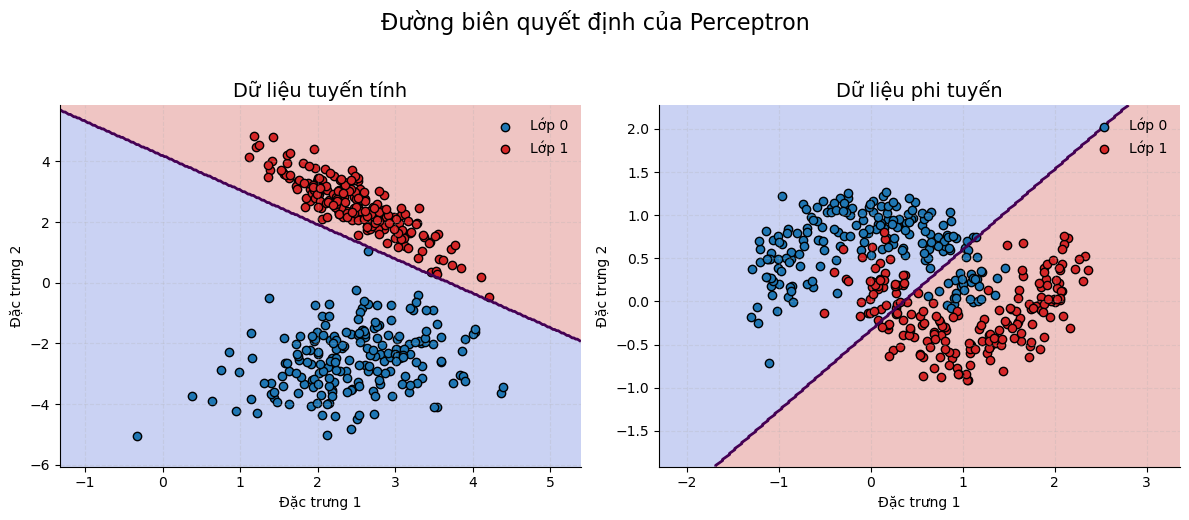

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, X, y, title in [
    (axes[0], perc_lin, X_lin, y_lin, "Dữ liệu tuyến tính"),
    (axes[1], perc_moon, X_moon, y_moon, "Dữ liệu phi tuyến")
]:
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0.5], linewidths=2)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], color="#1f77b4", label="Lớp 0", edgecolors="k")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color="#d62728", label="Lớp 1", edgecolors="k")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Đặc trưng 1")
    ax.set_ylabel("Đặc trưng 2")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

plt.suptitle("Đường biên quyết định của Perceptron", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "perceptron_decision_boundary.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Phân tích và nhận xét

In [ ]:
print("=== KẾT QUẢ THỰC NGHIỆM ===")
print(f"Số lỗi cuối cùng trên dữ liệu tuyến tính : {perc_lin.errors_per_epoch[-1]}")
print(f"Số lỗi cuối cùng trên dữ liệu phi tuyến  : {perc_moon.errors_per_epoch[-1]}")

=== KẾT QUẢ THỰC NGHIỆM ===
Số lỗi cuối cùng trên dữ liệu tuyến tính : 0
Số lỗi cuối cùng trên dữ liệu phi tuyến  : 75


**Nhận xét:**  
Kết quả thực nghiệm cho thấy Perceptron có hành vi khác nhau trên hai loại dữ liệu:
- **Dữ liệu phân chia tuyến tính:**  
  Số lỗi giảm dần và đạt giá trị 0. Điều này cho thấy Perceptron đã **hội tụ**, phù hợp với định lý hội tụ: nếu dữ liệu có thể phân chia tuyến tính, thuật toán sẽ tìm được siêu phẳng phân chia sau hữu hạn bước.

- **Dữ liệu không phân chia tuyến tính:**  
  Số lỗi không thể giảm về 0 mà dao động quanh một giá trị dương. Điều này cho thấy Perceptron **không thể hội tụ hoàn toàn** trên dữ liệu phi tuyến.

**Kết luận:** Perceptron hoạt động hiệu quả với dữ liệu có thể phân chia tuyến tính, nhưng có giới hạn rõ ràng khi dữ liệu không tuyến tính.

# B - LOGISTIC REGRESSION + L1/L2 + CLASS-WEIGHTED LOSS

## 1. Cơ sở lý thuyết

Logistic Regression là mô hình phân lớp xác suất, mô hình hóa trực tiếp:

\\[
p(y=1|x) = \sigma(w^T x + b)
\\]

trong đó hàm sigmoid là:

\\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\\]

Với bài toán nhị phân, loss tiêu chuẩn là cross-entropy:

\\[
E = -\sum_{n=1}^N \left[ y_n \log \hat{y}_n + (1-y_n)\log(1-\hat{y}_n)\right]
\\]

Trong bài này, để xử lý mất cân bằng dữ liệu, ta dùng **class-weighted loss**:

\\[
E = -\sum_{n=1}^N c_{y_n} \left[ y_n \log \hat{y}_n + (1-y_n)\log(1-\hat{y}_n)\right]
\\]
trong đó \\(c_{y_n}\\) là trọng số của lớp mà mẫu thứ \\(n\\) thuộc về, và các trọng số lớp được xác định theo:

\\[
c_k \propto \frac{N}{N_k}
\\]

Ngoài ra, để giảm overfitting, mô hình được regularize theo hai cách:

### L2 regularization
\\[
E = Loss + \frac{\lambda}{2m}\sum_j w_j^2
\\]

### L1 regularization
\\[
E = Loss + \frac{\lambda}{m}\sum_j |w_j|
\\]

Về mặt lý thuyết:
- L1 giúp tạo sparsity, tức nhiều hệ số về 0
- L2 giúp làm nhỏ trọng số và thường ổn định hơn

## 2. Cài đặt Logistic Regression từ đầu

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def compute_sample_weights(y, class_weights):
    return np.where(y == 1, class_weights[1], class_weights[0])

def compute_cost(X, y, w, b, lambda_=0.0, reg_type=None, class_weights=None):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)

    if class_weights is None:
        sample_weights = np.ones_like(y, dtype=float)
    else:
        sample_weights = compute_sample_weights(y, class_weights)

    data_loss = -np.sum(
        sample_weights * (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    ) / m

    reg_loss = 0.0
    if reg_type == "l2":
        reg_loss = (lambda_ / (2 * m)) * np.sum(w ** 2)
    elif reg_type == "l1":
        reg_loss = (lambda_ / m) * np.sum(np.abs(w))

    return data_loss + reg_loss

def compute_gradient(X, y, w, b, lambda_=0.0, reg_type=None, class_weights=None):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    if class_weights is None:
        sample_weights = np.ones_like(y, dtype=float)
    else:
        sample_weights = compute_sample_weights(y, class_weights)

    error = y_hat - y

    dw = (X.T @ (sample_weights * error)) / m
    db = np.sum(sample_weights * error) / m

    if reg_type == "l2":
        dw += (lambda_ / m) * w
    elif reg_type == "l1":
        dw += (lambda_ / m) * np.sign(w)

    return dw, db

In [ ]:
class LogisticRegressionScratch:
    def __init__(
        self,
        lr=0.01,
        n_iters=1000,
        lambda_=0.0,
        reg_type=None,
        class_weights=None,
        threshold=0.5,
        verbose=False
    ):
        self.lr = lr
        self.n_iters = n_iters
        self.lambda_ = lambda_
        self.reg_type = reg_type
        self.class_weights = class_weights
        self.threshold = threshold
        self.verbose = verbose

        self.w = None
        self.b = None
        self.cost_history = []
        self.train_time_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.cost_history = []

        start = time.time()

        for i in range(self.n_iters):
            dw, db = compute_gradient(
                X, y, self.w, self.b,
                lambda_=self.lambda_,
                reg_type=self.reg_type,
                class_weights=self.class_weights
            )

            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = compute_cost(
                X, y, self.w, self.b,
                lambda_=self.lambda_,
                reg_type=self.reg_type,
                class_weights=self.class_weights
            )
            self.cost_history.append(cost)

            if self.verbose and (i % 100 == 0 or i == self.n_iters - 1):
                print(f"Vòng lặp {i:4d} | Cost = {cost:.6f}")

        self.train_time_ = time.time() - start
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)

    def count_nonzero_weights(self, tol=1e-3):
        return np.sum(np.abs(self.w) > tol)

## 3. Chọn \\(\lambda\\) bằng Stratified K-Fold Cross Validation

Để chọn regularization strength \\(\lambda\\), ta dùng **Stratified K-Fold Cross Validation (k = 5)** trên tập train.

Lý do dùng Stratified K-Fold:
- giữ tỷ lệ lớp gần như không đổi ở mỗi fold
- phù hợp với bối cảnh dữ liệu mất cân bằng

Tiêu chí chọn \\(\lambda\\): **mean F1-score** trên validation folds.

In [ ]:
def compute_balanced_class_weights(y):
    classes, counts = np.unique(y, return_counts=True)
    n_samples = len(y)
    n_classes = len(classes)
    return {int(c): n_samples / (n_classes * cnt) for c, cnt in zip(classes, counts)}

def stratified_kfold_cv(
    X, y,
    lambdas,
    reg_type="l2",
    lr=0.01,
    n_iters=1000,
    n_splits=5,
    random_state=42
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for lam in lambdas:
        fold_acc = []
        fold_prec = []
        fold_rec = []
        fold_f1 = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]
            
            fold_weights = compute_balanced_class_weights(y_tr)

            model = LogisticRegressionScratch(
                lr=lr,
                n_iters=n_iters,
                lambda_=lam,
                reg_type=reg_type,
                class_weights=fold_weights,
                threshold=0.5,
                verbose=False
            )

            model.fit(X_tr, y_tr)
            y_va_pred = model.predict(X_va)

            fold_acc.append(accuracy_score(y_va, y_va_pred))
            fold_prec.append(precision_score(y_va, y_va_pred, zero_division=0))
            fold_rec.append(recall_score(y_va, y_va_pred, zero_division=0))
            fold_f1.append(f1_score(y_va, y_va_pred, zero_division=0))

        rows.append({
            "reg_type": reg_type,
            "lambda": lam,
            "mean_accuracy": np.mean(fold_acc),
            "std_accuracy": np.std(fold_acc),
            "mean_precision": np.mean(fold_prec),
            "std_precision": np.std(fold_prec),
            "mean_recall": np.mean(fold_rec),
            "std_recall": np.std(fold_rec),
            "mean_f1": np.mean(fold_f1),
            "std_f1": np.std(fold_f1),
        })

    results_df = pd.DataFrame(rows).sort_values(by="mean_f1", ascending=False).reset_index(drop=True)
    best_lambda = results_df.loc[0, "lambda"]
    return results_df, best_lambda

In [ ]:
lambda_grid = [0, 1, 10, 50, 100, 500, 1000]
print("Các giá trị lambda được thử:", lambda_grid)

Các giá trị lambda được thử: [0, 1, 10, 50, 100, 500, 1000]


In [ ]:
cv_l2_df, best_lambda_l2 = stratified_kfold_cv(
    X_train_np, y_train_np,
    lambdas=lambda_grid,
    reg_type="l2",
    lr=0.05,
    n_iters=800,
    n_splits=5,
    random_state=SEED
)

print("Giá trị lambda tốt nhất cho L2:", best_lambda_l2)
cv_l2_df

Giá trị lambda tốt nhất cho L2: 0


,reg_type,lambda,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,l2,0,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
1,l2,1,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
2,l2,10,0.860454,0.003261,0.834466,0.005703,0.845800,0.003360,0.840082,0.003365
3,l2,50,0.860388,0.003203,0.834256,0.005586,0.845927,0.003431,0.840038,0.003317
4,l2,100,0.860234,0.003230,0.834080,0.005581,0.845750,0.003536,0.839861,0.003363
5,l2,500,0.859629,0.003266,0.833221,0.005850,0.845318,0.003105,0.839213,0.003311
6,l2,1000,0.858210,0.003314,0.831229,0.005623,0.844252,0.003422,0.837678,0.003441


In [ ]:
cv_l1_df, best_lambda_l1 = stratified_kfold_cv(
    X_train_np, y_train_np,
    lambdas=lambda_grid,
    reg_type="l1",
    lr=0.05,
    n_iters=800,
    n_splits=5,
    random_state=SEED
)

print("Giá trị lambda tốt nhất cho L1:", best_lambda_l1)
cv_l1_df

Giá trị lambda tốt nhất cho L1: 10


,reg_type,lambda,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,l1,10,0.860542,0.003249,0.834480,0.005594,0.846029,0.003437,0.840202,0.003377
1,l1,0,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
2,l1,1,0.860454,0.003219,0.834448,0.005626,0.845826,0.003314,0.840086,0.003321
3,l1,50,0.860366,0.003461,0.834101,0.005968,0.846105,0.003431,0.840046,0.003576
4,l1,100,0.860157,0.003539,0.833904,0.006009,0.845800,0.003415,0.839797,0.003669
5,l1,500,0.858408,0.003334,0.831262,0.005894,0.844785,0.003661,0.837954,0.003431
6,l1,1000,0.854118,0.003285,0.825015,0.005180,0.841968,0.004303,0.833393,0.003550


**Nhận xét:**  
Cross-validation cho thấy các giá trị \\(\lambda\\) nhỏ và vừa cho kết quả khá gần nhau. Điều này gợi ý rằng bài toán hiện tại không quá nhạy với regularization strength, hoặc dữ liệu đã được tiền xử lý khá tốt trước đó.

## 4. Huấn luyện mô hình và tối ưu ngưỡng phân loại trên tập validation

Sau khi chọn được \\(\lambda\\) tốt nhất bằng cross-validation, ta huấn luyện hai mô hình:
- Logistic Regression + L1
- Logistic Regression + L2

trên tập **train**, sau đó dùng tập **validation** để:
1. so sánh hiệu năng giữa các mô hình
2. chọn ngưỡng phân loại tối ưu theo F1-score

Ta cũng huấn luyện thêm một baseline không dùng class weights để đánh giá tác động của weighted loss.

In [ ]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_th = 0.5
    best_f1 = -1

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    return best_th, best_f1

In [ ]:
logreg_l2 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=CLASS_WEIGHTS,
    threshold=0.5,
    verbose=True
)

logreg_l2.fit(X_train_np, y_train_np)
y_val_proba_l2 = logreg_l2.predict_proba(X_val_np)

best_th_l2, best_f1_l2 = find_best_threshold(y_val_np, y_val_proba_l2)
y_val_pred_l2 = (y_val_proba_l2 >= best_th_l2).astype(int)

print(f"Ngưỡng tốt nhất cho L2: {best_th_l2:.2f} | F1 tốt nhất: {best_f1_l2:.4f}")

result_l2_val = evaluate_classification(
    y_val_np, y_val_pred_l2, y_val_proba_l2,
    model_name="Logistic Regression + L2 (Validation)"
)

print()

logreg_l1 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l1,
    reg_type="l1",
    class_weights=CLASS_WEIGHTS,
    threshold=0.5,
    verbose=True
)

logreg_l1.fit(X_train_np, y_train_np)
logreg_l1.w[np.abs(logreg_l1.w) < 1e-6] = 0
y_val_proba_l1 = logreg_l1.predict_proba(X_val_np)

best_th_l1, best_f1_l1 = find_best_threshold(y_val_np, y_val_proba_l1)
y_val_pred_l1 = (y_val_proba_l1 >= best_th_l1).astype(int)

print(f"Ngưỡng tốt nhất cho L1: {best_th_l1:.2f} | F1 tốt nhất: {best_f1_l1:.4f}")

result_l1_val = evaluate_classification(
    y_val_np, y_val_pred_l1, y_val_proba_l1,
    model_name="Logistic Regression + L1 (Validation)"
)

Vòng lặp    0 | Cost = 0.675098
Vòng lặp  100 | Cost = 0.411539
Vòng lặp  200 | Cost = 0.388466
Vòng lặp  300 | Cost = 0.378698
Vòng lặp  400 | Cost = 0.372826
Vòng lặp  500 | Cost = 0.368673
Vòng lặp  600 | Cost = 0.365475
Vòng lặp  700 | Cost = 0.362887
Vòng lặp  800 | Cost = 0.360723
Vòng lặp  900 | Cost = 0.358872
Vòng lặp 1000 | Cost = 0.357263
Vòng lặp 1100 | Cost = 0.355845
Vòng lặp 1199 | Cost = 0.354595
Ngưỡng tốt nhất cho L2: 0.60 | F1 tốt nhất: 0.8451

===== Logistic Regression + L2 (Validation) =====
Accuracy : 0.8719
Precision: 0.8876
Recall   : 0.8065
F1-score : 0.8451

Classification Report:
              precision    recall  f1-score   support

           0     0.8617    0.9219    0.8908      7360
           1     0.8876    0.8065    0.8451      5628

    accuracy                         0.8719     12988
   macro avg     0.8746    0.8642    0.8679     12988
weighted avg     0.8729    0.8719    0.8710     12988

Confusion Matrix:
[[6785  575]
 [1089 4539]]
ROC-AUC  : 0.9

In [ ]:
baseline_l2 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=None,
    threshold=0.5,
    verbose=False
)

baseline_l2.fit(X_train_np, y_train_np)
baseline_val_proba = baseline_l2.predict_proba(X_val_np)

baseline_th, baseline_f1 = find_best_threshold(y_val_np, baseline_val_proba)
baseline_val_pred = (baseline_val_proba >= baseline_th).astype(int)

print(f"Ngưỡng tốt nhất cho baseline L2: {baseline_th:.2f} | F1 tốt nhất: {baseline_f1:.4f}")

baseline_result = evaluate_classification(
    y_val_np, baseline_val_pred, baseline_val_proba,
    model_name="Logistic Regression + L2 (Không dùng class weights)"
)

Ngưỡng tốt nhất cho baseline L2: 0.50 | F1 tốt nhất: 0.8452

===== Logistic Regression + L2 (Không dùng class weights) =====
Accuracy : 0.8692
Precision: 0.8675
Recall   : 0.8239
F1-score : 0.8452

Classification Report:
              precision    recall  f1-score   support

           0     0.8703    0.9038    0.8868      7360
           1     0.8675    0.8239    0.8452      5628

    accuracy                         0.8692     12988
   macro avg     0.8689    0.8639    0.8660     12988
weighted avg     0.8691    0.8692    0.8687     12988

Confusion Matrix:
[[6652  708]
 [ 991 4637]]
ROC-AUC  : 0.9229
AP       : 0.9274
Brier    : 0.1001


## 5. So sánh L1 và L2 regularization

L1 và L2 regularization có xu hướng ảnh hưởng khác nhau lên trọng số của mô hình:

- L1 regularization: có xu hướng đưa nhiều trọng số về 0, từ đó tạo sparsity.
- L2 regularization: làm nhỏ các trọng số nhưng hiếm khi đưa về 0, giúp mô hình ổn định hơn.

Để kiểm chứng điều này trong thực nghiệm, ta so sánh số lượng trọng số khác 0, độ lớn của vector trọng số và hệ số của từng đặc trưng giữa hai mô hình.

In [ ]:
nonzero_l1 = logreg_l1.count_nonzero_weights()
nonzero_l2 = logreg_l2.count_nonzero_weights()

print(f"Số trọng số khác 0 (L1): {nonzero_l1}/{len(logreg_l1.w)}")
print(f"Số trọng số khác 0 (L2): {nonzero_l2}/{len(logreg_l2.w)}")

print("\n=== Chuẩn của vector trọng số ===")
print(f"L1 model - ||w||_1 = {np.sum(np.abs(logreg_l1.w)):.4f}")
print(f"L2 model - ||w||_1 = {np.sum(np.abs(logreg_l2.w)):.4f}")
print(f"L1 model - ||w||_2 = {np.sqrt(np.sum(logreg_l1.w ** 2)):.4f}")
print(f"L2 model - ||w||_2 = {np.sqrt(np.sum(logreg_l2.w ** 2)):.4f}")

Số trọng số khác 0 (L1): 23/24
Số trọng số khác 0 (L2): 23/24

=== Chuẩn của vector trọng số ===
L1 model - ||w||_1 = 7.3419
L2 model - ||w||_1 = 7.3787
L1 model - ||w||_2 = 2.1601
L2 model - ||w||_2 = 2.1666


In [ ]:
if FEATURE_COLS is None:
    FEATURE_COLS = [f"x{i}" for i in range(X_train_np.shape[1])]

coef_compare = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef_l1": logreg_l1.w,
    "coef_l2": logreg_l2.w,
    "abs_l1": np.abs(logreg_l1.w),
    "abs_l2": np.abs(logreg_l2.w),
}).sort_values(by="abs_l2", ascending=False)

coef_compare.head(15)

,feature,coef_l1,coef_l2,abs_l1,abs_l2
3,Type of Travel,-1.347045,-1.349842,1.347045,1.349842
10,Online boarding,0.796757,0.797649,0.796757,0.797649
1,Customer Type,-0.759398,-0.763634,0.759398,0.763634
21,Class_Business,0.733523,0.734440,0.733523,0.734440
5,Inflight wifi service,0.522025,0.524789,0.522025,0.524789
22,Class_Eco,-0.463644,-0.465546,0.463644,0.465546
14,Leg room service,0.335320,0.335882,0.335320,0.335882
16,Checkin service,0.304829,0.305815,0.304829,0.305815
13,On-board service,0.304416,0.304776,0.304416,0.304776
12,Inflight entertainment,0.268279,0.268659,0.268279,0.268659


**Nhận xét:**  
Kết quả thực nghiệm trên bộ dữ liệu hiện tại cho thấy:
- số lượng trọng số khác 0 giữa hai mô hình không chênh lệch nhiều
- các đặc trưng có độ quan trọng lớn nhất giữa L1 và L2 khá tương đồng
- hiệu năng validation của hai mô hình gần như tương đương

Trên bài toán này, hiệu ứng sparsity của L1 **chưa rõ rệt**. Điều đó cho thấy regularization ở đây chủ yếu đóng vai trò kiểm soát độ lớn trọng số hơn là thực hiện lựa chọn đặc trưng mạnh mẽ.

**Kết luận:**  
Trong phạm vi dữ liệu hiện tại, chưa có bằng chứng thực nghiệm đủ mạnh để khẳng định L1 vượt trội hơn L2 về sparsity hoặc hiệu năng.

## 6. Đường cong loss

Đồ thị loss theo iteration giúp quan sát:
- tốc độ hội tụ
- độ ổn định của quá trình tối ưu
- mức khác biệt giữa L1 và L2 trong quá trình huấn luyện

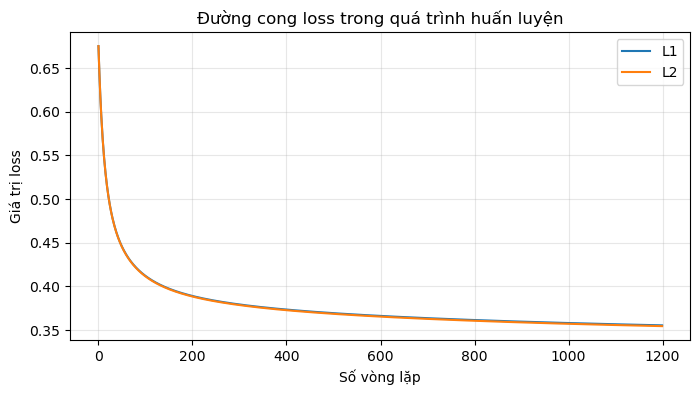

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(logreg_l1.cost_history, label="L1")
plt.plot(logreg_l2.cost_history, label="L2")
plt.title("Đường cong loss trong quá trình huấn luyện")
plt.xlabel("Số vòng lặp")
plt.ylabel("Giá trị loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIG_PATH, "logistic_loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
Đường cong loss của cả L1 và L2 đều giảm nhanh ở giai đoạn đầu và hội tụ dần sau đó. Hai đường gần như trùng nhau, cho thấy regularization không ảnh hưởng đáng kể đến quá trình hội tụ trong bài toán này.

# C - Đánh giá mô hình trên tập test

## 1. Huấn luyện mô hình cuối và dự đoán trên tập test

Quy trình:
1. Chọn mô hình tốt hơn dựa trên F1-score ở validation
2. Gộp train + validation
3. Huấn luyện lại mô hình cuối
4. Đánh giá một lần cuối trên test

In [ ]:
val_summary = pd.DataFrame([result_l1_val, result_l2_val]).sort_values(by="f1", ascending=False)
val_summary

,model,accuracy,precision,recall,f1,roc_auc,ap,brier
0,Logistic Regression + L1 (Validation),0.871882,0.887412,0.806681,0.845123,0.923024,0.927009,0.102836
1,Logistic Regression + L2 (Validation),0.871882,0.887564,0.806503,0.845094,0.923038,0.927004,0.102798


In [ ]:
X_trainval_np = np.vstack([X_train_np, X_val_np])
y_trainval_np = np.concatenate([y_train_np, y_val_np])

best_reg_type = val_summary.iloc[0]["model"]
print("Mô hình tốt nhất trên validation:", best_reg_type)

Mô hình tốt nhất trên validation: Logistic Regression + L1 (Validation)


In [ ]:
CLASS_WEIGHTS_TRAINVAL = compute_balanced_class_weights(y_trainval_np)

if "L1" in best_reg_type:
    final_model = LogisticRegressionScratch(
        lr=0.05,
        n_iters=1500,
        lambda_=best_lambda_l1,
        reg_type="l1",
        class_weights=CLASS_WEIGHTS_TRAINVAL,
        threshold=best_th_l1,
        verbose=True
    )
    final_model_name = "Final Logistic Regression + L1"
else:
    final_model = LogisticRegressionScratch(
        lr=0.05,
        n_iters=1500,
        lambda_=best_lambda_l2,
        reg_type="l2",
        class_weights=CLASS_WEIGHTS_TRAINVAL,
        threshold=best_th_l2,
        verbose=True
    )
    final_model_name = "Final Logistic Regression + L2"
    
final_model.fit(X_trainval_np, y_trainval_np)
y_test_pred = final_model.predict(X_test_np)
y_test_proba = final_model.predict_proba(X_test_np)

final_result = evaluate_classification(
    y_test_np, y_test_pred, y_test_proba,
    model_name=final_model_name
)

Vòng lặp    0 | Cost = 0.675120
Vòng lặp  100 | Cost = 0.412124
Vòng lặp  200 | Cost = 0.389052
Vòng lặp  300 | Cost = 0.379289
Vòng lặp  400 | Cost = 0.373440
Vòng lặp  500 | Cost = 0.369323
Vòng lặp  600 | Cost = 0.366160
Vòng lặp  700 | Cost = 0.363604
Vòng lặp  800 | Cost = 0.361469
Vòng lặp  900 | Cost = 0.359645
Vòng lặp 1000 | Cost = 0.358059
Vòng lặp 1100 | Cost = 0.356662
Vòng lặp 1200 | Cost = 0.355420
Vòng lặp 1300 | Cost = 0.354309
Vòng lặp 1400 | Cost = 0.353306
Vòng lặp 1499 | Cost = 0.352406

===== Final Logistic Regression + L1 =====
Accuracy : 0.8663
Precision: 0.8818
Recall   : 0.8029
F1-score : 0.8405

Classification Report:
              precision    recall  f1-score   support

           0     0.8559    0.9158    0.8848     14573
           1     0.8818    0.8029    0.8405     11403

    accuracy                         0.8663     25976
   macro avg     0.8689    0.8594    0.8627     25976
weighted avg     0.8673    0.8663    0.8654     25976

Confusion Matrix:
[[1

## 2. Ma trận nhầm lẫn

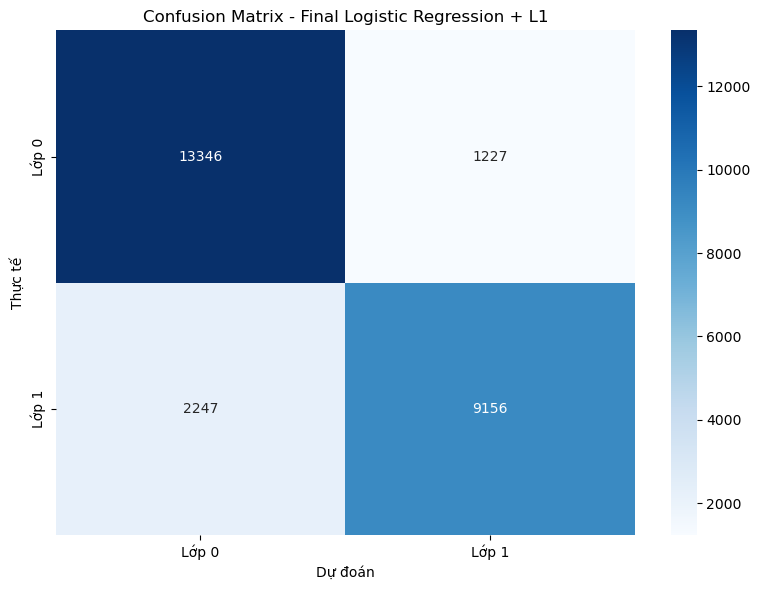

In [ ]:
# Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test_np, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Lớp 0", "Lớp 1"],
    yticklabels=["Lớp 0", "Lớp 1"],
    ax=ax
)

plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "confusion_matrix_final_model.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
Ma trận nhầm lẫn cho thấy mô hình phân loại đúng phần lớn các mẫu của cả hai lớp. Tuy nhiên, vẫn còn một số lượng đáng kể mẫu lớp 1 bị dự đoán sai thành lớp 0, cho thấy mô hình vẫn còn hạn chế trong việc nhận diện đầy đủ lớp dương.

## 3. ROC curve và Precision-Recall curve trên tập test

Để đánh giá hiệu năng của mô hình trên tập test, ta sử dụng ROC curve và Precision-Recall curve.  
Trong đó, ROC-AUC phản ánh khả năng phân biệt tổng quát giữa hai lớp, còn Precision-Recall curve đặc biệt hữu ích trong bối cảnh dữ liệu có thể mất cân bằng.

Để so sánh công bằng giữa các mô hình, ta huấn luyện lại các biến thể Logistic Regression (L1, L2 và baseline) trên toàn bộ tập train + validation trước khi đánh giá trên tập test.

In [ ]:
# Retrain các model trên train + validation
l1_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l1,
    reg_type="l1",
    class_weights=CLASS_WEIGHTS_TRAINVAL,
    threshold=best_th_l1
)
l1_full.fit(X_trainval_np, y_trainval_np)

l2_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=CLASS_WEIGHTS_TRAINVAL,
    threshold=best_th_l2
)
l2_full.fit(X_trainval_np, y_trainval_np)

baseline_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=None,
    threshold=baseline_th
)
baseline_full.fit(X_trainval_np, y_trainval_np)

# Predict xác suất trên test
y_proba_l1_test = l1_full.predict_proba(X_test_np)
y_proba_l2_test = l2_full.predict_proba(X_test_np)
y_proba_baseline_test = baseline_full.predict_proba(X_test_np)

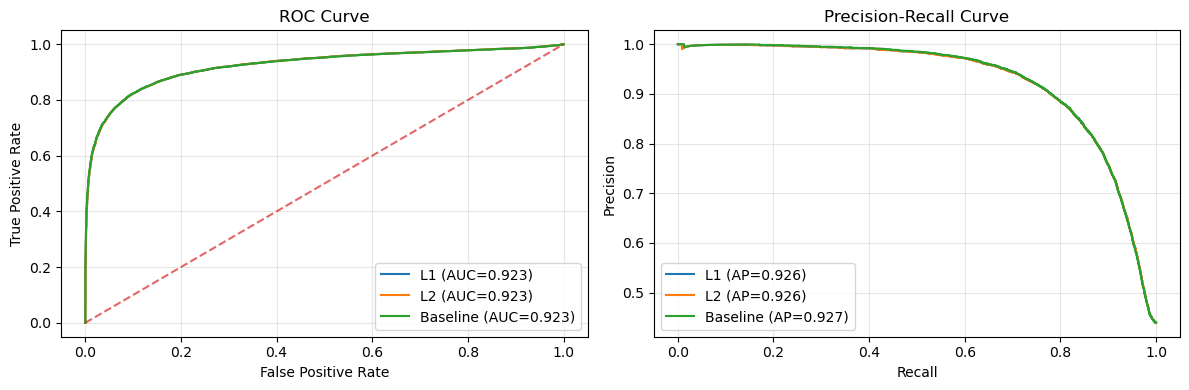

In [ ]:
plt.figure(figsize=(12, 4))

# ROC
plt.subplot(1, 2, 1)
for name, y_proba in [
    ("L1", y_proba_l1_test),
    ("L2", y_proba_l2_test),
    ("Baseline", y_proba_baseline_test)
]:
    fpr, tpr, _ = roc_curve(y_test_np, y_proba)
    auc = roc_auc_score(y_test_np, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.7)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

# PR
plt.subplot(1, 2, 2)

for name, y_proba in [
    ("L1", y_proba_l1_test),
    ("L2", y_proba_l2_test),
    ("Baseline", y_proba_baseline_test)
]:
    precision, recall, _ = precision_recall_curve(y_test_np, y_proba)
    ap = average_precision_score(y_test_np, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "roc_pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
ROC curve cho thấy cả ba mô hình đều có khả năng phân biệt giữa hai lớp khá tốt, AUC ≈ 0.92. Điều này cho thấy Logistic Regression hoạt động hiệu quả trong việc xếp hạng các mẫu theo xác suất thuộc lớp dương.

Tuy nhiên, các đường ROC của L1, L2 và baseline gần như chồng lên nhau, cho thấy sự khác biệt về khả năng phân biệt tổng thể giữa các mô hình là không đáng kể.

Precision-Recall curve cho thấy hiệu năng trên lớp dương là ổn định. Các mô hình L1, L2 và baseline có đường cong gần như trùng nhau, với AP ≈ 0.926-0.927, cho thấy sự khác biệt về hiệu năng giữa các mô hình là không đáng kể.

Kết quả này cho thấy regularization và class-weighted loss không mang lại cải thiện rõ rệt trên tập dữ liệu này.

## 4. McNemar’s Test

McNemar’s test được dùng để kiểm định xem hai mô hình có khác biệt thống kê hay không trên **cùng một tập test**.  
Khác với việc chỉ so sánh Accuracy hay F1-score, kiểm định này tập trung vào những mẫu mà hai mô hình dự đoán khác nhau.

Trong notebook này, McNemar’s test được dùng để so sánh:
- Logistic Regression + L1 và Logistic Regression + L2
- Logistic Regression + L2 và baseline
- Logistic Regression + L1 và baseline

In [ ]:
def mcnemar_table(y_true, pred_a, pred_b):
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)

    n01 = np.sum((a_correct == True)  & (b_correct == False))  # A đúng, B sai
    n10 = np.sum((a_correct == False) & (b_correct == True))   # A sai, B đúng

    table = np.array([
        [0, n01],
        [n10, 0]
    ])
    return table, n01, n10

def mcnemar_test(y_true, pred_a, pred_b, model_a="A", model_b="B", exact=True):
    _, n01, n10 = mcnemar_table(y_true, pred_a, pred_b)
    n = n01 + n10

    print(f"\n=== McNemar: {model_a} vs. {model_b} ===")
    print(f"{model_a} đúng, {model_b} sai : {n01}")
    print(f"{model_a} sai,  {model_b} đúng: {n10}")

    if n == 0:
        print("Hai mô hình dự đoán giống nhau trên toàn bộ test set.")
        return {"model_a": model_a, "model_b": model_b, "statistic": 0.0, "p_value": 1.0}

    if exact:
        p_value = binomtest(k=min(n01, n10), n=n, p=0.5, alternative="two-sided").pvalue
        statistic = None
        print(f"p-value (exact) = {p_value:.6f}")
    else:
        # Xấp xỉ chi-square có continuity correction
        statistic = (abs(n01 - n10) - 1)**2 / n
        p_value = 1 - chi2.cdf(statistic, df=1)
        print(f"Chi-square statistic = {statistic:.6f}")
        print(f"p-value = {p_value:.6f}")

    if p_value < 0.05:
        print("Kết luận: khác biệt có ý nghĩa thống kê ở mức 5%.")
    else:
        print("Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.")

    return {
        "model_a": model_a,
        "model_b": model_b,
        "statistic": statistic,
        "p_value": p_value,
        "n01": n01,
        "n10": n10
    }

# Dự đoán nhãn trên tập test
y_pred_l1_test = (y_proba_l1_test >= best_th_l1).astype(int)
y_pred_l2_test = (y_proba_l2_test >= best_th_l2).astype(int)
y_pred_baseline_test = (y_proba_baseline_test >= baseline_th).astype(int)

# So sánh các mô hình bằng McNemar
mcnemar_l1_l2 = mcnemar_test(
    y_test_np, y_pred_l1_test, y_pred_l2_test,
    model_a="L1", model_b="L2", exact=True
)

mcnemar_l2_base = mcnemar_test(
    y_test_np, y_pred_l2_test, y_pred_baseline_test,
    model_a="L2", model_b="Baseline", exact=True
)

mcnemar_l1_base = mcnemar_test(
    y_test_np, y_pred_l1_test, y_pred_baseline_test,
    model_a="L1", model_b="Baseline", exact=True
)

mcnemar_df = pd.DataFrame([mcnemar_l1_l2, mcnemar_l2_base, mcnemar_l1_base])
mcnemar_df


=== McNemar: L1 vs. L2 ===
L1 đúng, L2 sai : 2
L1 sai,  L2 đúng: 5
p-value (exact) = 0.453125
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.

=== McNemar: L2 vs. Baseline ===
L2 đúng, Baseline sai : 222
L2 sai,  Baseline đúng: 224
p-value (exact) = 0.962240
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.

=== McNemar: L1 vs. Baseline ===
L1 đúng, Baseline sai : 220
L1 sai,  Baseline đúng: 225
p-value (exact) = 0.849635
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.


,model_a,model_b,statistic,p_value,n01,n10
0,L1,L2,None,0.453125,2,5
1,L2,Baseline,None,0.962240,222,224
2,L1,Baseline,None,0.849635,220,225


**Nhận xét:**  
Kết quả McNemar’s test cho thấy tất cả các cặp mô hình đều có p-value lớn hơn 0.05:
- L1 vs L2: p ≈ 0.45 
- L2 vs Baseline: p ≈ 0.96
- L1 vs Baseline: p ≈ 0.85  

Điều này cho thấy **không có sự khác biệt có ý nghĩa thống kê** giữa các mô hình trên cùng tập test.

Mặc dù có sự chênh lệch nhỏ về số lượng dự đoán đúng giữa các mô hình, nhưng các chênh lệch này có thể do yếu tố ngẫu nhiên thay vì phản ánh sự khác biệt thực sự về hiệu năng.

**Kết luận:**  
Các mô hình Logistic Regression với L1, L2 và baseline có hiệu năng tương đương về mặt thống kê trên bài toán này.

## 5. Phân tích Calibration 

Đối với các mô hình phân lớp xác suất như Logistic Regression, không chỉ cần dự đoán đúng nhãn mà còn cần đầu ra xác suất phải **đáng tin cậy**.

Ví dụ: Nếu mô hình gán xác suất khoảng 0.8 cho nhiều mẫu, thì lý tưởng là khoảng 80% trong số đó thực sự thuộc lớp dương.

Để kiểm tra điều này, ta dùng:
- **Reliability diagram**
- **Brier score**

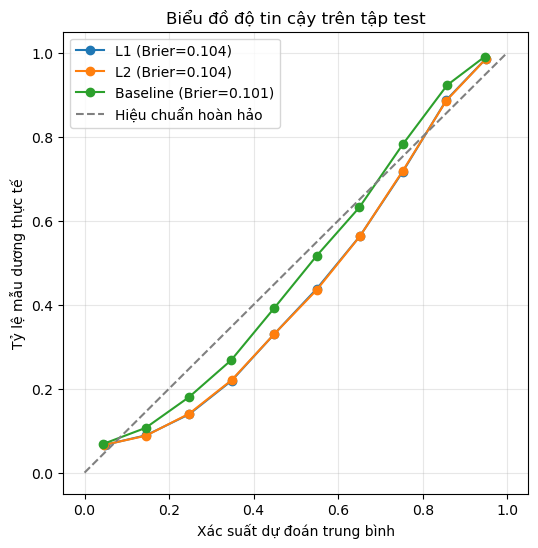

=== Bảng đánh giá calibration trên tập test ===


,model,brier_score,roc_auc,ap
0,L1,0.103876,0.923121,0.926023
1,L2,0.103847,0.923128,0.926006
2,Baseline,0.101202,0.923032,0.926575


In [ ]:
def plot_reliability_diagram(y_true, prob_dict, n_bins=10, save_path=None):
    plt.figure(figsize=(6, 6))

    for name, y_proba in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy="uniform")
        brier = brier_score_loss(y_true, y_proba)
        plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hiệu chuẩn hoàn hảo")
    plt.xlabel("Xác suất dự đoán trung bình")
    plt.ylabel("Tỷ lệ mẫu dương thực tế")
    plt.title("Biểu đồ độ tin cậy trên tập test")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_reliability_diagram(
    y_test_np,
    {
        "L1": y_proba_l1_test,
        "L2": y_proba_l2_test,
        "Baseline": y_proba_baseline_test
    },
    n_bins=10,
    save_path=os.path.join(FIG_PATH, "reliability_diagram.png")
)

calibration_df = pd.DataFrame({
    "model": ["L1", "L2", "Baseline"],
    "brier_score": [
        brier_score_loss(y_test_np, y_proba_l1_test),
        brier_score_loss(y_test_np, y_proba_l2_test),
        brier_score_loss(y_test_np, y_proba_baseline_test)
    ],
    "roc_auc": [
        roc_auc_score(y_test_np, y_proba_l1_test),
        roc_auc_score(y_test_np, y_proba_l2_test),
        roc_auc_score(y_test_np, y_proba_baseline_test)
    ],
    "ap": [
        average_precision_score(y_test_np, y_proba_l1_test),
        average_precision_score(y_test_np, y_proba_l2_test),
        average_precision_score(y_test_np, y_proba_baseline_test)
    ]
})

print("=== Bảng đánh giá calibration trên tập test ===")
display(calibration_df)

**Nhận xét:**  
Biểu đồ độ tin cậy cho thấy cả ba mô hình đều có đường cong khá gần với đường chéo (hiệu chuẩn hoàn hảo), cho thấy xác suất đầu ra của các mô hình tương đối đáng tin cậy.

Tuy nhiên, các đường cong có xu hướng nằm dưới đường chéo ở một số khoảng xác suất, cho thấy mô hình có xu hướng **dự đoán hơi quá tự tin** (overconfident) trong một số vùng.

Brier score của các mô hình là:
- L1: ≈ 0.104  
- L2: ≈ 0.104  
- Baseline: ≈ 0.101  

Giá trị Brier score giữa các mô hình gần như tương đương, trong đó baseline có giá trị thấp hơn nhẹ, cho thấy xác suất dự đoán của baseline có độ chính xác tổng thể nhỉnh hơn một chút.

**Kết luận:**  
Các mô hình có mức độ calibration tương tự nhau, và việc sử dụng regularization hoặc class-weighted loss không mang lại cải thiện đáng kể về độ tin cậy của xác suất đầu ra.

## 6. Bảng tổng kết kết quả

Bảng này tổng hợp:
- Thí nghiệm Perceptron trên dữ liệu toy
- Logistic Regression L1/L2 trên validation
- Mô hình cuối trên test

In [ ]:
summary_df = pd.DataFrame([
    {
        "model": "Perceptron - linear toy data",
        "accuracy": lin_result["accuracy"],
        "precision": lin_result["precision"],
        "recall": lin_result["recall"],
        "f1": lin_result["f1"],
        "roc_auc": np.nan,
        "ap": np.nan,
        "brier": np.nan
    },
    {
        "model": "Perceptron - nonlinear toy data",
        "accuracy": moon_result["accuracy"],
        "precision": moon_result["precision"],
        "recall": moon_result["recall"],
        "f1": moon_result["f1"],
        "roc_auc": np.nan,
        "ap": np.nan,
        "brier": np.nan
    },
    {
        "model": result_l1_val["model"],
        "accuracy": result_l1_val["accuracy"],
        "precision": result_l1_val["precision"],
        "recall": result_l1_val["recall"],
        "f1": result_l1_val["f1"],
        "roc_auc": result_l1_val.get("roc_auc", np.nan),
        "ap": result_l1_val.get("ap", np.nan),
        "brier": result_l1_val.get("brier", np.nan)
    },
    {
        "model": result_l2_val["model"],
        "accuracy": result_l2_val["accuracy"],
        "precision": result_l2_val["precision"],
        "recall": result_l2_val["recall"],
        "f1": result_l2_val["f1"],
        "roc_auc": result_l2_val.get("roc_auc", np.nan),
        "ap": result_l2_val.get("ap", np.nan),
        "brier": result_l2_val.get("brier", np.nan)
    },
    {
        "model": baseline_result["model"],
        "accuracy": baseline_result["accuracy"],
        "precision": baseline_result["precision"],
        "recall": baseline_result["recall"],
        "f1": baseline_result["f1"],
        "roc_auc": baseline_result.get("roc_auc", np.nan),
        "ap": baseline_result.get("ap", np.nan),
        "brier": baseline_result.get("brier", np.nan)
    },
    {
        "model": final_result["model"],
        "accuracy": final_result["accuracy"],
        "precision": final_result["precision"],
        "recall": final_result["recall"],
        "f1": final_result["f1"],
        "roc_auc": final_result.get("roc_auc", np.nan),
        "ap": final_result.get("ap", np.nan),
        "brier": final_result.get("brier", np.nan)
    }
])

summary_df

,model,accuracy,precision,recall,f1,roc_auc,ap,brier
0,Perceptron - linear toy data,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
1,Perceptron - nonlinear toy data,0.800000,0.819149,0.770000,0.793814,NaN,NaN,NaN
2,Logistic Regression + L1 (Validation),0.871882,0.887412,0.806681,0.845123,0.923024,0.927009,0.102836
3,Logistic Regression + L2 (Validation),0.871882,0.887564,0.806503,0.845094,0.923038,0.927004,0.102798
4,Logistic Regression + L2 (Không dùng class wei...,0.869187,0.867540,0.823916,0.845165,0.922890,0.927383,0.100071
5,Final Logistic Regression + L1,0.866261,0.881826,0.802947,0.840540,0.923121,0.926023,0.103876


## 7. Lưu kết quả

In [ ]:
best_lambda_final = best_lambda_l1 if "L1" in final_model_name else best_lambda_l2
best_threshold_final = best_th_l1 if "L1" in final_model_name else best_th_l2

save = {
    # Model cuối
    "final_model": final_model,
    "final_model_name": final_model_name,

    # Hyperparameter quan trọng
    "best_lambda": best_lambda_final,
    "best_threshold": best_threshold_final,

    # Kết quả chính
    "final_result": final_result,
    "val_summary": val_summary,
    "summary_df": summary_df,

    # Phân tích bổ sung
    "mcnemar_df": mcnemar_df,
    "calibration_df": calibration_df,
}

out_pkl = os.path.join(DATA_DIR, "perceptron_logreg_results.pkl")

with open(out_pkl, "wb") as f:
    pickle.dump(save, f)

print(f"Đã lưu: {out_pkl}")

Đã lưu: /home/thucquyen/Machine-Learning---Project-1-/data/processed/perceptron_logreg_results.pkl


# D - Phân tích và thảo luận

## 1. Perceptron
Perceptron được cài đặt từ đầu để minh họa định lý hội tụ.  
Kết quả trên dữ liệu toy cho thấy:
- với dữ liệu tuyến tính, số lỗi có thể giảm về 0
- với dữ liệu phi tuyến, Perceptron không thể hội tụ hoàn toàn vì đường biên quyết định luôn là tuyến tính

Điều này cho thấy Perceptron phù hợp để minh họa bản chất của bộ phân lớp tuyến tính, nhưng có giới hạn rõ ràng khi cấu trúc dữ liệu không phân chia tuyến tính.

## 2. Logistic Regression với regularization
Logistic Regression ổn định hơn Perceptron vì mô hình hóa xác suất và tối ưu cross-entropy loss.  
Việc thêm regularization giúp kiểm soát độ lớn trọng số và hạn chế overfitting.

Tuy nhiên, trên bộ dữ liệu hiện tại:
- L1 và L2 cho hiệu năng gần như tương đương
- số lượng trọng số khác 0 không chênh lệch nhiều
- hiệu ứng sparsity của L1 chưa thể hiện rõ

Vì vậy, trong phạm vi thực nghiệm này, chưa có bằng chứng mạnh cho thấy L1 vượt trội hơn L2 về lựa chọn đặc trưng hay hiệu năng.

## 3. Class-weighted loss
Mô hình baseline (không sử dụng class weights) được dùng làm mốc so sánh.

Kết quả thực nghiệm cho thấy sự khác biệt giữa mô hình có và không sử dụng class-weighted loss là không đáng kể trên cả tập validation và test. 
Điều này phù hợp với đặc điểm của bộ dữ liệu, khi mức độ mất cân bằng giữa hai lớp là không quá lớn.

Do đó, việc sử dụng class-weighted loss trong trường hợp này không mang lại cải thiện rõ rệt về hiệu năng, đặc biệt đối với các chỉ số như F1-score hay Recall.

## 4. Kiểm định ý nghĩa thống kê và phân tích hiệu chuẩn xác suất
Kết quả McNemar’s test cho thấy p-value giữa các cặp mô hình đều lớn hơn mức ý nghĩa 0.05, cho thấy không có sự khác biệt có ý nghĩa thống kê giữa các mô hình.

Biểu đồ độ tin cậy cho thấy các đường cong của L1, L2 và baseline nằm gần đường chéo, cho thấy xác suất dự đoán của các mô hình tương đối được hiệu chuẩn tốt. 
Brier score của các mô hình cũng gần như tương đương, củng cố nhận định rằng chất lượng xác suất đầu ra giữa các mô hình không khác biệt đáng kể.

Kết hợp hai phân tích này, có thể kết luận rằng các biến thể Logistic Regression (L1, L2 và baseline) có hành vi tương tự nhau trên bài toán này, cả về khả năng phân loại và độ tin cậy của xác suất dự đoán.

# Kết luận

Trong notebook này, hai nhóm mô hình đã được cài đặt và phân tích:

- **Perceptron**: minh họa rõ hành vi hội tụ trên dữ liệu tuyến tính và giới hạn trên dữ liệu phi tuyến
- **Logistic Regression với L1/L2 regularization**: cho phép mô hình hóa xác suất, kiểm soát độ phức tạp mô hình và xử lý mất cân bằng bằng class-weighted loss

Kết quả thực nghiệm cho thấy:
- Perceptron chỉ phù hợp với dữ liệu có thể phân chia tuyến tính
- Logistic Regression ổn định hơn cho bài toán phân lớp thực tế
- L1 và L2 cho hiệu năng gần nhau trên bộ dữ liệu này
- class-weighted loss, McNemar’s test và phân tích calibration giúp việc đánh giá mô hình đầy đủ và đáng tin cậy hơn

Nhìn chung, notebook đã cho thấy vai trò của regularization và weighted loss trong Logistic Regression, đồng thời minh họa rõ giới hạn của các mô hình tuyến tính.